# 相位相干测试：模拟数据生成

本 notebook 当前只生成测试数据，不进行小波变换或相干度计算。数组轴顺序固定为 $(x,y,t)$，波沿 $x$ 方向传播，且在 $y$ 方向均匀。

正向波为

$$
V_+(x,y,t)=A\left(t-\frac{x}{v_{\rm ph}}\right)\cos(k_0x-\omega_0t),
$$

反射层 $x=x_r$ 左侧的反向波为

$$
V_-(x,y,t)=rA\left(t-\frac{2x_r-x}{v_{\rm ph}}\right)\cos(-k_0x-\omega_0t+2k_0x_r+\phi_r).
$$

采用 `stmorlet` 默认参数 $k_{\rm M}=\omega_{\rm M}=6$、$\epsilon=1$。在目标 $(k_0,\omega_0)$ 处，小波的空间和时间高斯尺度为

$$
a_s=\frac{k_{\rm M}}{k_0},\qquad a_t=\frac{\omega_{\rm M}}{\omega_0}.
$$

数据边界按 $\pm4a_s$ 和 $\pm4a_t$ 留出裕量；高斯因子在 $4\sigma$ 处已经下降至 $e^{-8}\approx3.35\times10^{-4}$。

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from stmorlet import Morlet2D1T

In [5]:
# -------------------- 采样与数组轴 --------------------
nx, ny, nt = 256, 128, 512
dx = dy = dt = 1.0
x = np.arange(nx, dtype=np.float64) * dx
y = np.arange(ny, dtype=np.float64) * dy
t = np.arange(nt, dtype=np.float64) * dt

# 广播后的第 0、1、2 轴依次对应 x、y、t
x3 = x[:, None, None]
t3 = t[None, None, :]
y_uniform = np.ones((1, ny, 1), dtype=np.float32)

# -------------------- 波与 Morlet 参数 --------------------
wavelength = 12.0 * dx
phase_speed = 1.0 * dx / dt
k = 2.0 * np.pi / wavelength
omega = k * phase_speed
period = 2.0 * np.pi / omega

morlet_k0 = 6.0
morlet_omega0 = 6.0
epsilon = 1.0
a_s = morlet_k0 / k
a_t = morlet_omega0 / omega
support_sigma = 4.0
margin_x = int(np.ceil(support_sigma * a_s / dx))
margin_y = int(np.ceil(support_sigma * np.sqrt(epsilon) * a_s / dy))
margin_t = int(np.ceil(support_sigma * a_t / dt))

# -------------------- 反射模型 --------------------
reflection_x = 176.0 * dx
reflection_amplitude = 0.5
reflection_phase = 0.0
reflection_taper_width = 4.0 * dx
analysis_x = (64.0 * dx, 112.0 * dx)

print(f'data shape (x, y, t): {(nx, ny, nt)}')
print(f'wavelength={wavelength:.2f}, period={period:.2f}')
print(f'a_s={a_s:.3f}, a_t={a_t:.3f}')
print(f'four-sigma margins: x={margin_x}, y={margin_y}, t={margin_t} samples')

data shape (x, y, t): (256, 128, 512)
wavelength=12.00, period=12.00
a_s=11.459, a_t=11.459
four-sigma margins: x=46, y=46, t=46 samples


In [6]:
# 非周期、非对称的公共包络，使时间延迟具有唯一、可识别的特征。
pulse_amplitudes = np.array([1.00, 0.65, 0.85], dtype=np.float64)
pulse_centers = np.array([40.0, 90.0, 140.0], dtype=np.float64) * dt
pulse_widths = np.array([18.0, 24.0, 15.0], dtype=np.float64) * dt

def envelope(retarded_time):
    result = np.zeros_like(retarded_time, dtype=np.float64)
    for amplitude, center, width in zip(
        pulse_amplitudes, pulse_centers, pulse_widths
    ):
        result += amplitude * np.exp(
            -0.5 * ((retarded_time - center) / width) ** 2
        )
    return result

# 沿 +x 传播：cos(kx - omega*t)
retarded_time_plus = t3 - x3 / phase_speed
phase_plus = k * x3 - omega * t3
v_plus_xt = envelope(retarded_time_plus) * np.cos(phase_plus)
v_plus = (v_plus_xt * y_uniform).astype(np.float32)

# 沿 -x 传播。平滑门函数只让反射波存在于反射层左侧；
# 后续分析区域与门函数之间保留超过 4 sigma 的空间距离。
retarded_time_minus = t3 - (2.0 * reflection_x - x3) / phase_speed
phase_minus = (
    -k * x3 - omega * t3 + 2.0 * k * reflection_x + reflection_phase
)
reflection_gate = 0.5 * (
    1.0 - np.tanh((x3 - reflection_x) / reflection_taper_width)
)
v_minus_xt = (
    reflection_amplitude
    * reflection_gate
    * envelope(retarded_time_minus)
    * np.cos(phase_minus)
)
v_minus = (v_minus_xt * y_uniform).astype(np.float32)

# 第一轮为无噪声、单层反射数据。
data = v_plus + v_minus

assert data.shape == (nx, ny, nt)
assert data.dtype == np.float32
assert analysis_x[0] >= margin_x * dx
assert reflection_x - analysis_x[1] >= margin_x * dx
assert ny * dy >= 2.0 * margin_y * dy

expected_delay_range = (
    2.0 * (reflection_x - analysis_x[1]) / phase_speed,
    2.0 * (reflection_x - analysis_x[0]) / phase_speed,
)
print(f'data dtype: {data.dtype}')
print(f'analysis x range: {analysis_x}')
print(f'expected delay range in analysis region: {expected_delay_range}')

data dtype: float32
analysis x range: (64.0, 112.0)
expected delay range in analysis region: (128.0, 224.0)


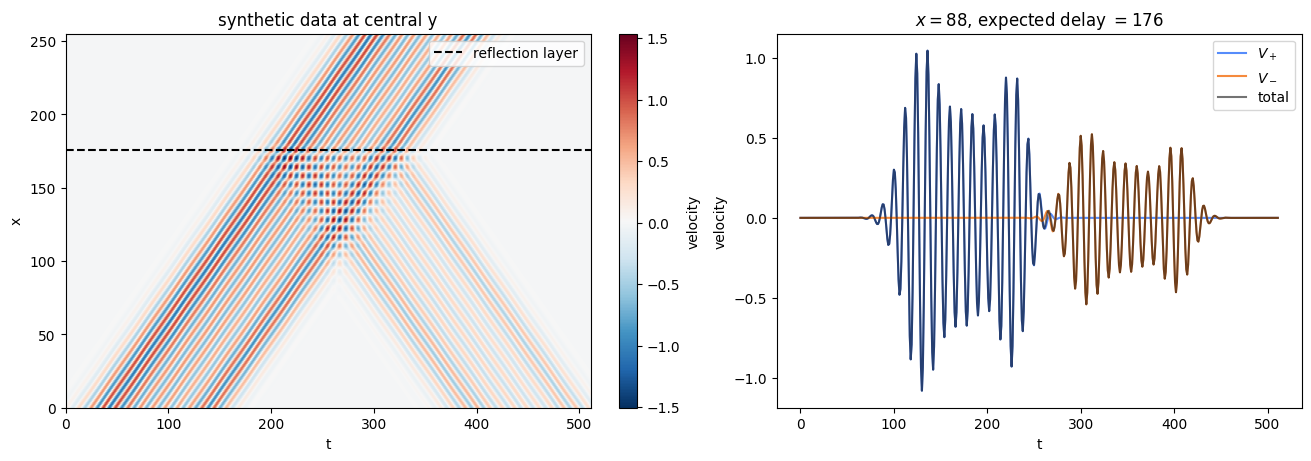

In [7]:
# 仅检查生成的数据，不进行小波或相干分析。
y_index = ny // 2
x_observe = 88.0 * dx
x_index = int(round(x_observe / dx))
expected_delay = 2.0 * (reflection_x - x[x_index]) / phase_speed

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
extent = [t[0], t[-1], x[0], x[-1]]
image = axes[0].imshow(
    data[:, y_index, :],
    origin='lower',
    aspect='auto',
    extent=extent,
    cmap='RdBu_r',
)
axes[0].axhline(reflection_x, color='black', linestyle='--', label='reflection layer')
axes[0].set(xlabel='t', ylabel='x', title='synthetic data at central y')
axes[0].legend()
fig.colorbar(image, ax=axes[0], label='velocity')

axes[1].plot(t, v_plus[x_index, y_index], label=r'$V_+$')
axes[1].plot(t, v_minus[x_index, y_index], label=r'$V_-$')
axes[1].plot(t, data[x_index, y_index], color='black', alpha=0.55, label='total')
axes[1].set(
    xlabel='t',
    ylabel='velocity',
    title=fr'$x={x[x_index]:.0f}$, expected delay $={expected_delay:.0f}$',
)
axes[1].legend()
plt.show()

In [8]:
morlet = Morlet2D1T(
    dx=dx,
    dy=dy,
    dt=dt,
    epsilon=epsilon,
    k0=6,
    omega0=6.0,
    precision="single",
    backend="gpu",
    device=0,
    boundary=None,
)

In [5]:
k_array = k * np.linspace(0.5, 1.5, 9)
omega_array = omega * np.linspace(0.5, 1.5, 9)
theta_array = np.linspace(-10, 10, 9) + 180

In [6]:
psd_plus_path = morlet.psd_polar(v_plus, k_array, theta_array, omega_array, output="memmap", path='./data/test_psd_plus.npy', overwrite=True)

PSD polar:   0%|          | 0/9 [00:00<?, ?block/s]

In [7]:
psd_plus = np.load('./data/test_psd_plus.npy', mmap_mode="r")
psd_plus_f = np.mean(psd_plus, axis=(0, 1, 2))

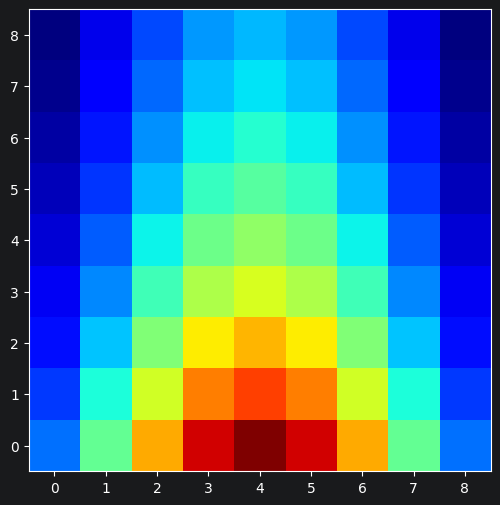

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(np.mean(psd_plus_f, axis=2), origin='lower', cmap='jet')

In [10]:
k_array = k * np.linspace(0.5, 1.5, 9)
omega_array = omega * np.linspace(0.5, 1.5, 9)
theta_plus_array = np.linspace(-10, 10, 9)
theta_minus_array = 180 + theta_plus_array

In [12]:
w_test_plus = morlet.cwt_polar(data, k_array, theta_plus_array, omega_array, output="memmap", path='./data/test_coe_plus.npy', overwrite=True)
w_test_minus = morlet.cwt_polar(data, k_array, theta_minus_array, omega_array, output="memmap", path='./data/test_coe_minus.npy', overwrite=True)

CWT polar:   0%|          | 0/9 [00:00<?, ?block/s]

CWT polar:   0%|          | 0/9 [00:00<?, ?block/s]

In [13]:
w_plus = np.load('./data/test_coe_plus.npy', mmap_mode="r")[64:113, 46:82, 46:466, 4, 4, 4]
w_minus = np.load('./data/test_coe_minus.npy', mmap_mode="r")[64:113, 46:82, 46:466, 4, 4, 4]

In [14]:
lag_array = np.arange(100, 241, dtype=int)

nx_valid, ny_valid, nt_valid = w_plus.shape
max_lag = lag_array.max()
n_common = nt_valid - max_lag

gamma2 = np.full((nx_valid, len(lag_array)), np.nan, dtype=np.float64)

wp = w_plus[:, :, :n_common]

power_plus = np.mean(np.abs(wp) ** 2, axis=(1, 2))

for i, lag in enumerate(lag_array):
    wm = w_minus[:, :, lag:lag + n_common]
    s_pm = np.mean(wp * np.conj(wm), axis=(1, 2))
    power_minus = np.mean(np.abs(wm) ** 2, axis=(1, 2))
    denominator = power_plus * power_minus

    np.divide(
        np.abs(s_pm) ** 2,
        denominator,
        out=gamma2[:, i],
        where=denominator > 0,
    )

gamma2 = np.clip(gamma2, 0.0, 1.0)

In [16]:
x_valid = x[64:113]
tau_array = lag_array * dt

tau_theory = (
    2.0 * (reflection_x - x_valid)
    / phase_speed
)

best_index = np.nanargmax(gamma2, axis=1)
tau_measured = tau_array[best_index]
gamma2_max = gamma2[np.arange(nx_valid), best_index]

delay_error = tau_measured - tau_theory

print("gamma2 range:",
      np.nanmin(gamma2), np.nanmax(gamma2))
print("mean peak gamma2:",
      np.nanmean(gamma2_max))
print("mean absolute delay error:",
      np.nanmean(np.abs(delay_error)))

gamma2 range: 0.18404853343963623 1.0
mean peak gamma2: 0.9999999744551522
mean absolute delay error: 0.0


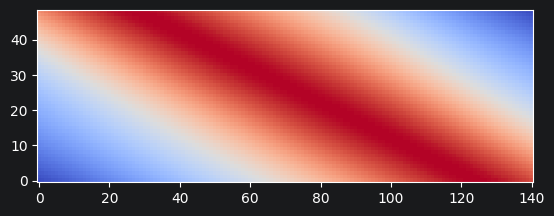

In [17]:
fig, ax = plt.subplots()
ax.imshow(gamma2, origin='lower', cmap='coolwarm')

## 背景流导致正、反传波相速度不同的测试

在均匀外流 $U$ 中，固定观测频率 $\omega$ 的正、反传 Alfvénic 波分别满足

$$
k_+=\frac{\omega}{v_A+U},\qquad
k_-=\frac{\omega}{v_A-U}.
$$

因此相干性应在同一 $\omega$ 下配对 $(k_+,\theta)$ 与 $(k_-,\theta+180^\circ)$，而不是强制两者使用相同的 $k$。

下面构造一个共同的非周期波包。波包从左侧向外传播，在 $x=x_r$ 线性反射后返回。在观测位置 $x$ 处，理论延迟为

$$
\tau(x)=(x_r-x)\left(\frac{1}{v_A+U}+\frac{1}{v_A-U}\right).
$$

测试同时计算两种情况：

1. **正确匹配**：反传分支使用 $k_-$；
2. **错误的同波数匹配**：反传分支仍使用 $k_+$。

合成数据加入可重复的宽带噪声，以避免在无噪声单色波中出现“即使远离真实分支，极小的小波泄漏也可能得到很高的归一化相干度”这一退化情形。

In [9]:
# -------------------- 含背景流的合成波场 --------------------
alfven_speed = phase_speed
background_flow = 0.25 * alfven_speed
speed_plus = alfven_speed + background_flow
speed_minus = alfven_speed - background_flow

# 静态反射层保持观测系频率 omega 不变，但两个分支的波数不同。
k_plus_flow = omega / speed_plus
k_minus_flow = omega / speed_minus

assert 0.0 <= background_flow < alfven_speed
assert not np.isclose(k_plus_flow, k_minus_flow)

retarded_plus_flow = t3 - x3 / speed_plus
phase_plus_flow = k_plus_flow * x3 - omega * t3
v_plus_flow_xt = envelope(retarded_plus_flow) * np.cos(phase_plus_flow)

# 波包先以 speed_plus 到达反射层，再以 speed_minus 返回观测点。
retarded_minus_flow = (
    t3
    - reflection_x / speed_plus
    - (reflection_x - x3) / speed_minus
)

# 常数项保证正、反传载波在 x=reflection_x 处相位连续，
# 并叠加反射附加相位 reflection_phase。
phase_minus_flow = (
    -k_minus_flow * x3
    - omega * t3
    + (k_plus_flow + k_minus_flow) * reflection_x
    + reflection_phase
)
v_minus_flow_xt = (
    reflection_amplitude
    * reflection_gate
    * envelope(retarded_minus_flow)
    * np.cos(phase_minus_flow)
)

rng_flow = np.random.default_rng(20260903)
flow_noise_sigma = 0.35
flow_noise = rng_flow.normal(0.0, flow_noise_sigma, size=(nx, ny, nt)).astype(np.float32)

v_plus_flow = (v_plus_flow_xt * y_uniform).astype(np.float32)
v_minus_flow = (v_minus_flow_xt * y_uniform).astype(np.float32)
data_flow = v_plus_flow + v_minus_flow + flow_noise

flow_margin_x = int(np.ceil(support_sigma * morlet_k0 / min(k_plus_flow, k_minus_flow) / dx))
flow_margin_y = int(np.ceil(support_sigma * np.sqrt(epsilon) * morlet_k0 / min(k_plus_flow, k_minus_flow) / dy))
flow_margin_t = int(np.ceil(support_sigma * morlet_omega0 / omega / dt))

flow_x_slice = slice(64, 113)
flow_y_slice = slice(flow_margin_y, ny - flow_margin_y)
flow_t_slice = slice(flow_margin_t, nt - flow_margin_t)

assert flow_x_slice.start >= flow_margin_x
assert reflection_x / dx - flow_x_slice.stop >= flow_margin_x
assert flow_y_slice.stop > flow_y_slice.start

x_flow_valid = x[flow_x_slice]
tau_flow_theory = (reflection_x - x_flow_valid) * (
    1.0 / speed_plus + 1.0 / speed_minus
)

print(f'v_A={alfven_speed:.3f}, U={background_flow:.3f}')
print(f'v_plus={speed_plus:.3f}, v_minus={speed_minus:.3f}')
print(f'k_plus={k_plus_flow:.5f}, k_minus={k_minus_flow:.5f}')
print(f'lambda_plus={2*np.pi/k_plus_flow:.2f}, lambda_minus={2*np.pi/k_minus_flow:.2f}')
print(f'valid y indices: [{flow_y_slice.start}, {flow_y_slice.stop})')
print(f'theoretical delay range: {tau_flow_theory.min():.2f} -- {tau_flow_theory.max():.2f}')

v_A=1.000, U=0.250
v_plus=1.250, v_minus=0.750
k_plus=0.41888, k_minus=0.69813
lambda_plus=15.00, lambda_minus=9.00
valid y indices: [58, 70)
theoretical delay range: 136.53 -- 238.93


In [10]:
# -------------------- stmorlet 复小波系数 --------------------
# 只取一个目标频率和沿 +/-x 的两个方向。
# 三次变换依次是：正传真实分支、反传真实分支、反传错误的同 k 分支。
flow_omega_array = np.array([omega], dtype=np.float64)
flow_theta_plus = np.array([0.0], dtype=np.float64)
flow_theta_minus = np.array([180.0], dtype=np.float64)

flow_coe_plus_path = morlet.cwt_polar(
    data_flow,
    np.array([k_plus_flow]),
    flow_theta_plus,
    flow_omega_array,
    output='memmap',
    path='./data/test_flow_coe_plus.npy',
    overwrite=True,
)
flow_coe_minus_matched_path = morlet.cwt_polar(
    data_flow,
    np.array([k_minus_flow]),
    flow_theta_minus,
    flow_omega_array,
    output='memmap',
    path='./data/test_flow_coe_minus_matched.npy',
    overwrite=True,
)
flow_coe_minus_same_k_path = morlet.cwt_polar(
    data_flow,
    np.array([k_plus_flow]),
    flow_theta_minus,
    flow_omega_array,
    output='memmap',
    path='./data/test_flow_coe_minus_same_k.npy',
    overwrite=True,
)

def load_flow_branch(path):
    return np.load(path, mmap_mode='r')[
        flow_x_slice, flow_y_slice, flow_t_slice, 0, 0, 0
    ]

w_plus_flow = load_flow_branch(flow_coe_plus_path)
w_minus_flow_matched = load_flow_branch(flow_coe_minus_matched_path)
w_minus_flow_same_k = load_flow_branch(flow_coe_minus_same_k_path)

print('coefficient sub-cube shape:', w_plus_flow.shape)

CWT polar:   0%|          | 0/1 [00:00<?, ?block/s]

CWT polar:   0%|          | 0/1 [00:00<?, ?block/s]

CWT polar:   0%|          | 0/1 [00:00<?, ?block/s]

coefficient sub-cube shape: (49, 12, 420)


In [11]:
# -------------------- 延迟相干度 --------------------
def lagged_coherence_by_x(wp, wm, lag_samples):
    """按 x 返回 gamma^2(x, lag)。

    对每个 lag 使用相同长度的正传时间片段，并在 y,t 上平均，
    避免不同 lag 因样本数不同而产生额外偏差。
    """
    lag_samples = np.asarray(lag_samples, dtype=int)
    if np.any(lag_samples < 0):
        raise ValueError('this test only scans non-negative reflection delays')

    max_lag = int(lag_samples.max())
    n_common = wp.shape[2] - max_lag
    if n_common <= 0:
        raise ValueError('lag range is too long for the valid time interval')

    wp_common = wp[:, :, :n_common]
    s_pp = np.mean(np.abs(wp_common) ** 2, axis=(1, 2))
    result = np.full((wp.shape[0], lag_samples.size), np.nan, dtype=np.float64)

    for lag_index, lag in enumerate(lag_samples):
        wm_shifted = wm[:, :, lag:lag + n_common]
        s_pm = np.mean(wp_common * np.conj(wm_shifted), axis=(1, 2))
        s_mm = np.mean(np.abs(wm_shifted) ** 2, axis=(1, 2))
        denominator = s_pp * s_mm
        np.divide(
            np.abs(s_pm) ** 2,
            denominator,
            out=result[:, lag_index],
            where=denominator > 0,
        )

    return np.clip(result, 0.0, 1.0)


lag_flow = np.arange(110, 261, dtype=int)
tau_flow = lag_flow * dt

gamma2_flow_matched = lagged_coherence_by_x(
    w_plus_flow, w_minus_flow_matched, lag_flow
)
gamma2_flow_same_k = lagged_coherence_by_x(
    w_plus_flow, w_minus_flow_same_k, lag_flow
)

best_matched_index = np.nanargmax(gamma2_flow_matched, axis=1)
best_same_k_index = np.nanargmax(gamma2_flow_same_k, axis=1)

tau_flow_measured = tau_flow[best_matched_index]
tau_flow_same_k = tau_flow[best_same_k_index]
gamma2_flow_peak = gamma2_flow_matched[
    np.arange(x_flow_valid.size), best_matched_index
]
gamma2_flow_same_k_peak = gamma2_flow_same_k[
    np.arange(x_flow_valid.size), best_same_k_index
]

flow_delay_error = tau_flow_measured - tau_flow_theory

print(f'mean matched peak gamma^2: {np.nanmean(gamma2_flow_peak):.4f}')
print(f'mean same-k peak gamma^2:  {np.nanmean(gamma2_flow_same_k_peak):.4f}')
print(f'mean absolute delay error: {np.nanmean(np.abs(flow_delay_error)):.3f}')
print(f'max absolute delay error:  {np.nanmax(np.abs(flow_delay_error)):.3f}')

# 这些是合成数据的回归测试阈值，不是观测数据的显著性标准。
assert np.nanmean(gamma2_flow_peak) > 0.70
assert np.nanmean(np.abs(flow_delay_error)) < 8.0
assert np.nanmean(gamma2_flow_peak) > np.nanmean(gamma2_flow_same_k_peak) + 0.20

print('PASS: 按照背景流修正后的 (k_plus, k_minus) 匹配可恢复高相干和正确延迟。')

mean matched peak gamma^2: 0.9999
mean same-k peak gamma^2:  0.3017
mean absolute delay error: 0.286
max absolute delay error:  0.733
PASS: 按照背景流修正后的 (k_plus, k_minus) 匹配可恢复高相干和正确延迟。


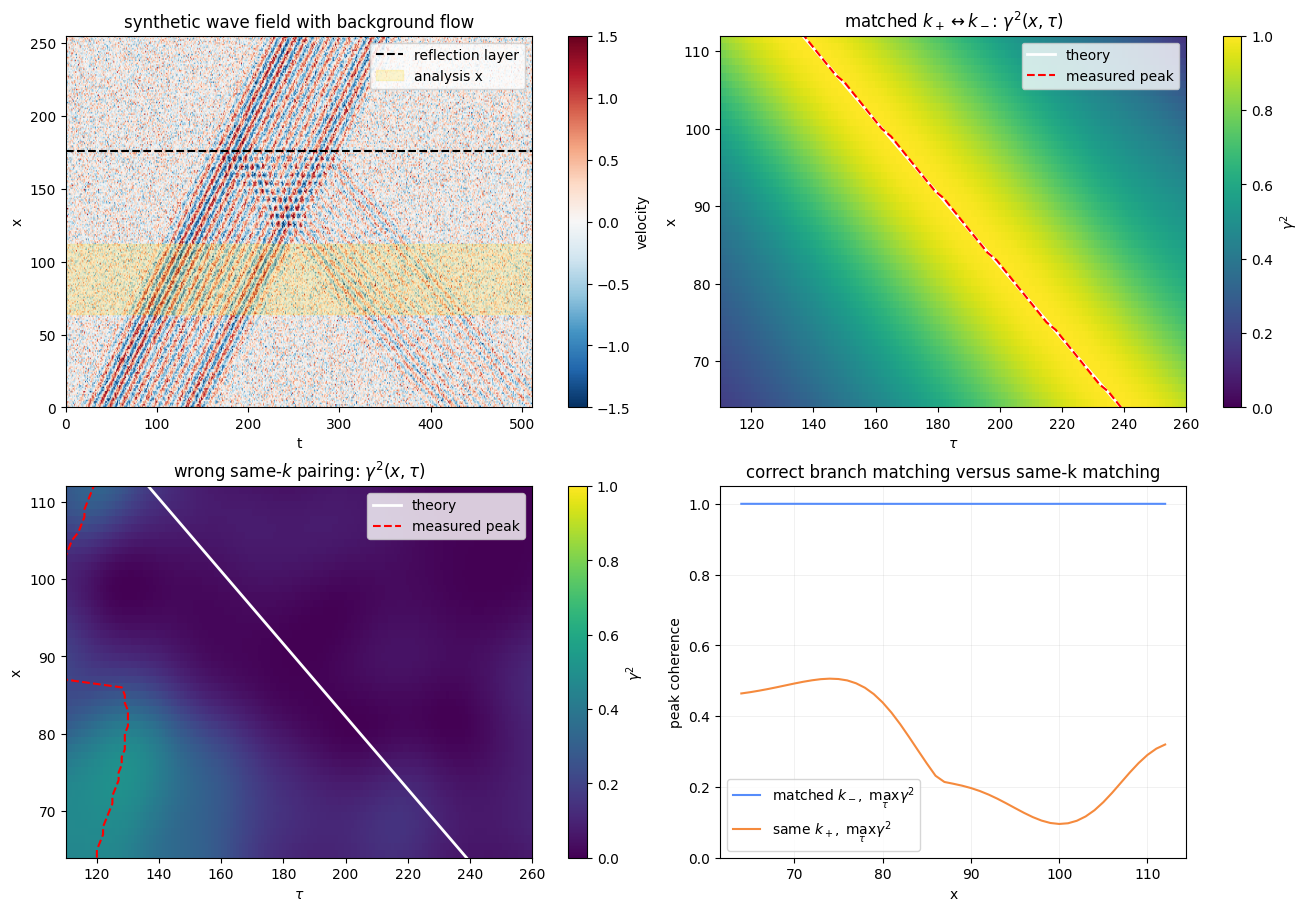

In [12]:
# -------------------- 结果可视化 --------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

flow_extent = [t[0], t[-1], x[0], x[-1]]
flow_image = axes[0, 0].imshow(
    data_flow[:, ny // 2, :],
    origin='lower',
    aspect='auto',
    extent=flow_extent,
    cmap='RdBu_r',
    vmin=-1.5,
    vmax=1.5,
)
axes[0, 0].axhline(reflection_x, color='black', linestyle='--', label='reflection layer')
axes[0, 0].axhspan(
    x_flow_valid[0], x_flow_valid[-1], color='gold', alpha=0.18, label='analysis x'
)
axes[0, 0].set(xlabel='t', ylabel='x', title='synthetic wave field with background flow')
axes[0, 0].legend(loc='upper right')
fig.colorbar(flow_image, ax=axes[0, 0], label='velocity')

coh_extent = [tau_flow[0], tau_flow[-1], x_flow_valid[0], x_flow_valid[-1]]
matched_image = axes[0, 1].imshow(
    gamma2_flow_matched,
    origin='lower',
    aspect='auto',
    extent=coh_extent,
    cmap='viridis',
    vmin=0.0,
    vmax=1.0,
)
axes[0, 1].plot(tau_flow_theory, x_flow_valid, color='white', linewidth=2, label='theory')
axes[0, 1].plot(tau_flow_measured, x_flow_valid, color='red', linestyle='--', label='measured peak')
axes[0, 1].set(
    xlabel=r'$\tau$', ylabel='x',
    title=r'matched $k_+ \leftrightarrow k_-$: $\gamma^2(x,\tau)$',
)
axes[0, 1].legend()
fig.colorbar(matched_image, ax=axes[0, 1], label=r'$\gamma^2$')

same_k_image = axes[1, 0].imshow(
    gamma2_flow_same_k,
    origin='lower',
    aspect='auto',
    extent=coh_extent,
    cmap='viridis',
    vmin=0.0,
    vmax=1.0,
)
axes[1, 0].plot(tau_flow_theory, x_flow_valid, color='white', linewidth=2, label='theory')
axes[1, 0].plot(tau_flow_same_k, x_flow_valid, color='red', linestyle='--', label='measured peak')
axes[1, 0].set(
    xlabel=r'$\tau$', ylabel='x',
    title=r'wrong same-$k$ pairing: $\gamma^2(x,\tau)$',
)
axes[1, 0].legend()
fig.colorbar(same_k_image, ax=axes[1, 0], label=r'$\gamma^2$')

axes[1, 1].plot(x_flow_valid, gamma2_flow_peak, label=r'matched $k_-,\;\max_\tau\gamma^2$')
axes[1, 1].plot(x_flow_valid, gamma2_flow_same_k_peak, label=r'same $k_+,\;\max_\tau\gamma^2$')
axes[1, 1].set(
    xlabel='x', ylabel='peak coherence', ylim=(0.0, 1.05),
    title='correct branch matching versus same-k matching',
)
axes[1, 1].grid(alpha=0.25)
axes[1, 1].legend()

plt.show()

### 判读

若上述断言通过，说明背景流并不会使延迟相干性本身失效；需要修正的是参数分支的配对规则和理论延迟：

$$
(k_+,\theta,\omega)
\longleftrightarrow
(k_-,\theta+180^\circ,\omega),
$$

$$
\tau=(x_r-x)\left[(v_A+U)^{-1}+(v_A-U)^{-1}\right].
$$

需要注意：这个测试的 $U$ 是均匀常数。若 $U(s)$ 或 $v_A(s)$ 随路径变化，波数匹配和延迟都应改为沿传播路径的局域关系与积分。此合成测试中的 `assert` 仅是方法回归检查，不可当作真实观测的显著性阈值；真实数据仍需要 phase-randomized surrogate 和多重检验校正。